In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../data/db/bluestock_mf.db")

nav = pd.read_sql("SELECT * FROM fact_nav", engine)
fund_master = pd.read_sql("SELECT * FROM dim_fund", engine)
aum = pd.read_sql("SELECT * FROM fact_aum", engine)
sip = pd.read_sql("SELECT * FROM fact_sip_industry", engine)
transactions = pd.read_sql("SELECT * FROM fact_transactions", engine)
folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nav["nav_date"] = pd.to_datetime(nav["nav_date"])

print("NAV rows:", len(nav))
print("Fund master rows:", len(fund_master))


NAV rows: 46000
Fund master rows: 40


In [2]:
fig = px.line(
    nav.sort_values(["amfi_code", "nav_date"]),
    x="nav_date",
    y="nav",
    color="amfi_code",
    title="NAV Trend — All 40 Schemes (2022–2026)"
)

# 2023 bull run
fig.add_vrect(x0="2023-03-01", x1="2023-12-31", fillcolor="green", opacity=0.10,
              line_width=0, annotation_text="2023 bull run", annotation_position="top left")

# 2024 corrections
for x0, x1, label, yshift in [("2024-01-15", "2024-03-15", "Q1-24", 0),
                              ("2024-06-01", "2024-06-30", "Jun-24", -22),
                              ("2024-10-01", "2024-11-30", "Oct-Nov-24", -44)]:
    fig.add_vrect(x0=x0, x1=x1, fillcolor="red", opacity=0.14, line_width=0,
                  annotation_text=label + " correction", annotation_position="top left",
                  annotation=dict(yshift=yshift, font_size=11, font_color="firebrick"))

fig.update_layout(showlegend=False, height=600,
                  xaxis_title="Date", yaxis_title="NAV (Rs.)")
fig.show()

In [3]:
import os
os.makedirs("../reports/charts", exist_ok=True)
CHARTS = "../reports/charts"

In [4]:
import os
os.makedirs("../reports/charts", exist_ok=True)

In [5]:
fig.write_image("../reports/charts/01_nav_trend_all_funds.png", width=1500, height=650, scale=2)


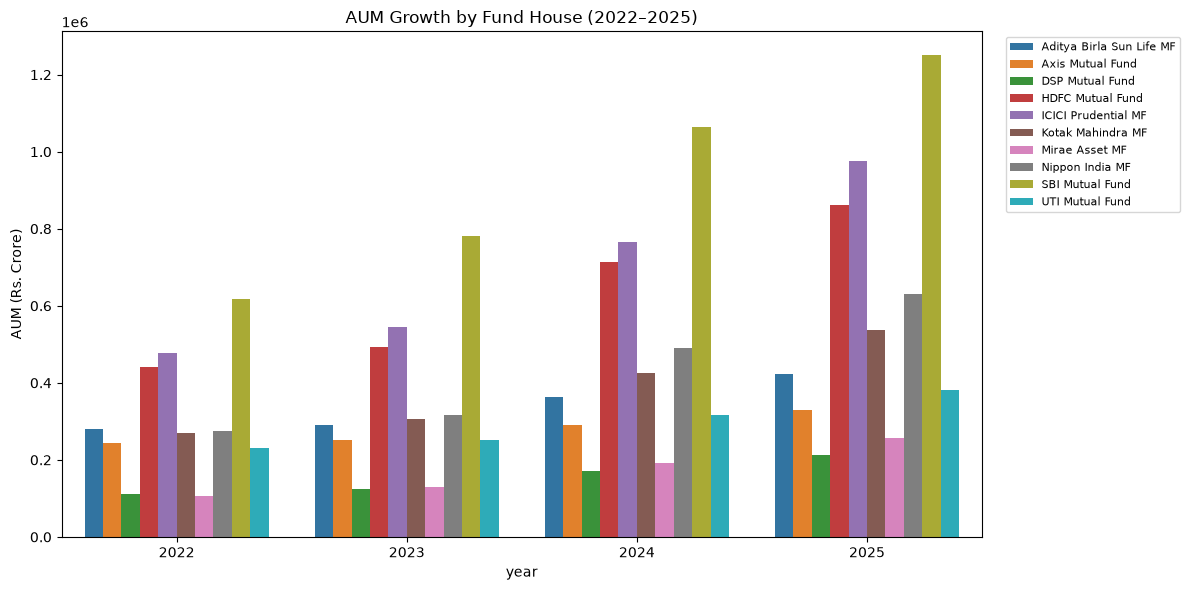

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

aum_yearly = aum.groupby(["year", "fund_house"])["aum_crore"].mean().reset_index()

sns.barplot(data=aum_yearly, x="year", y="aum_crore", hue="fund_house", ax=ax)
ax.set_title("AUM Growth by Fund House (2022–2025)")
ax.set_ylabel("AUM (Rs. Crore)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/charts/02_aum_growth_by_house.png", dpi=200)
plt.show()

In [7]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip.sort_values("month"),
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow (Jan 2022 – Dec 2025)"
)

peak_date = sip["month"].max()
peak_value = sip["sip_inflow_crore"].max()

fig.add_annotation(
    x=peak_date.strftime("%Y-%m-%d"),
    y=peak_value,
    text="₹31,002 Cr — All-Time High (Dec 2025)",
    showarrow=True,
    arrowhead=2,
    ax=-80,
    ay=-40
)

fig.update_layout(height=500)
fig.show()
fig.write_image("../reports/charts/03_sip_inflow_trend.png")

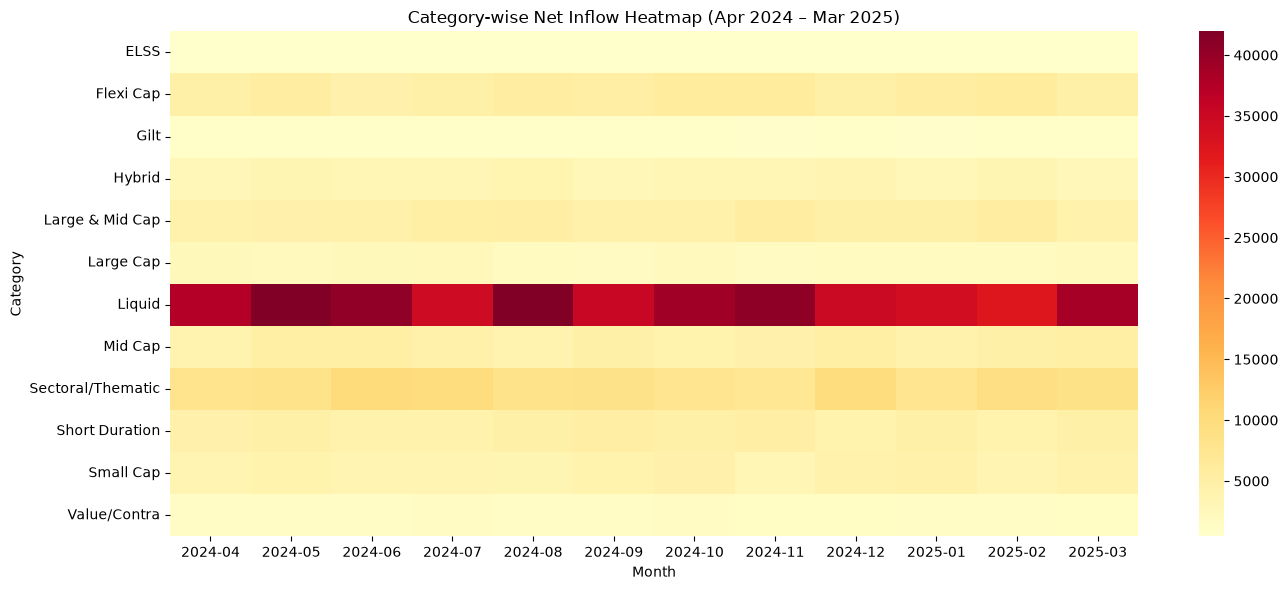

In [8]:
category_inflows = pd.read_csv("../data/raw/05_category_inflows.csv")

heatmap_data = category_inflows.pivot(index="category", columns="month", values="net_inflow_crore")

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, ax=ax)
ax.set_title("Category-wise Net Inflow Heatmap (Apr 2024 – Mar 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Category")
plt.tight_layout()
plt.savefig("../reports/charts/04_category_inflow_heatmap.png", dpi=200)
plt.show()

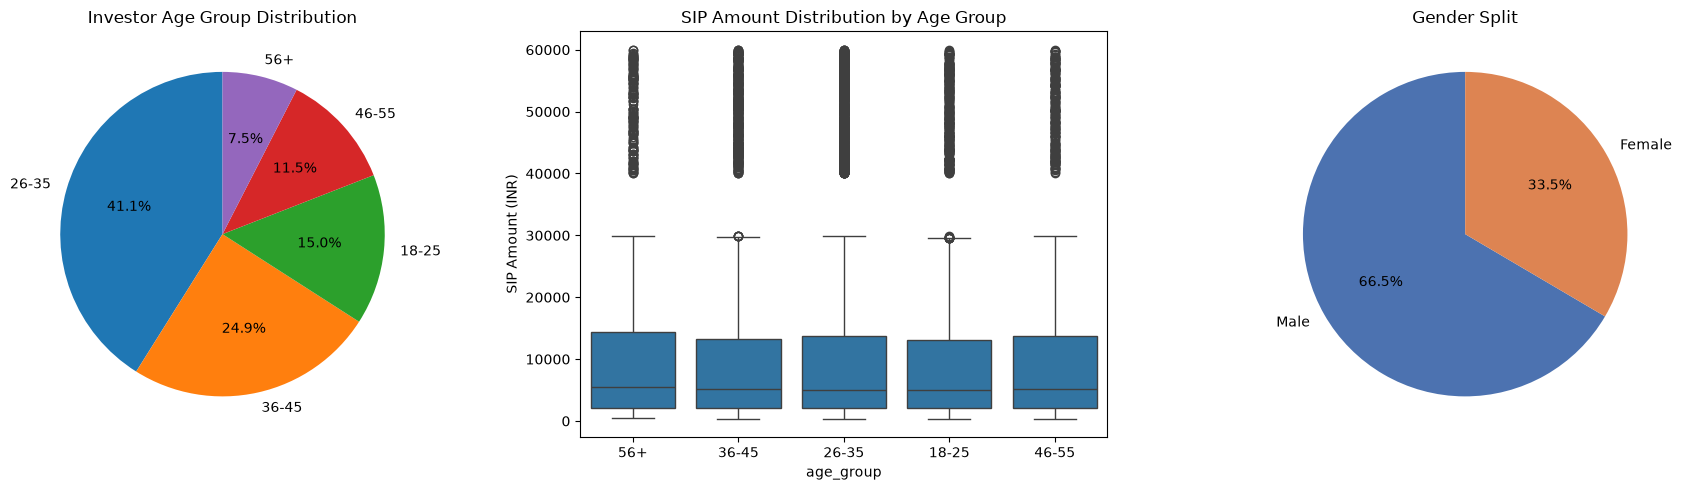

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Age group distribution pie chart
age_counts = transactions["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Investor Age Group Distribution")

# 2. SIP amount box plot by age group
sip_only = transactions[transactions["transaction_type"] == "Sip"]
sns.boxplot(data=sip_only, x="age_group", y="amount_inr", ax=axes[1])
axes[1].set_title("SIP Amount Distribution by Age Group")
axes[1].set_ylabel("SIP Amount (INR)")

# 3. Gender split
gender_counts = transactions["gender"].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90, colors=["#4C72B0", "#DD8452"])
axes[2].set_title("Gender Split")

plt.tight_layout()
plt.savefig("../reports/charts/05_investor_demographics.png", dpi=200)
plt.show()

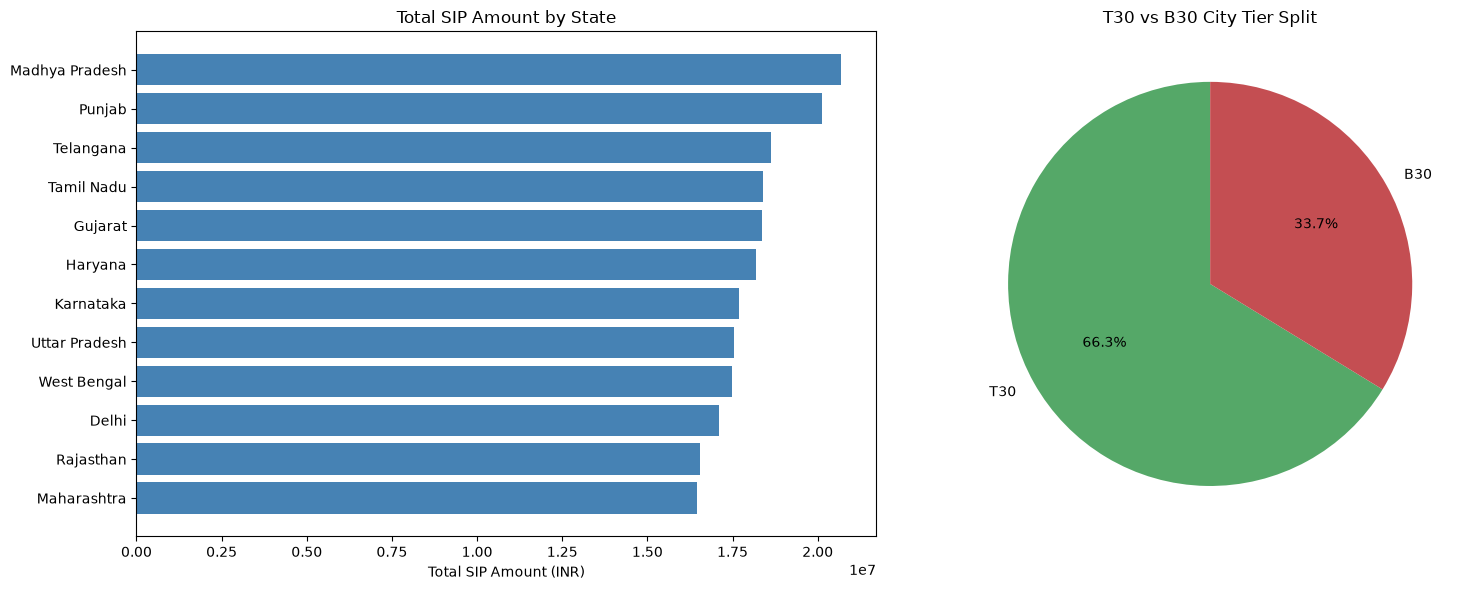

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar chart — SIP amount by state
state_sip = transactions[transactions["transaction_type"] == "Sip"].groupby("state")["amount_inr"].sum().sort_values()
axes[0].barh(state_sip.index, state_sip.values, color="steelblue")
axes[0].set_title("Total SIP Amount by State")
axes[0].set_xlabel("Total SIP Amount (INR)")

# T30 vs B30 pie chart
tier_counts = transactions["city_tier"].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%", startangle=90, colors=["#55A868", "#C44E52"])
axes[1].set_title("T30 vs B30 City Tier Split")

plt.tight_layout()
plt.savefig("../reports/charts/06_geographic_distribution.png", dpi=200)
plt.show()

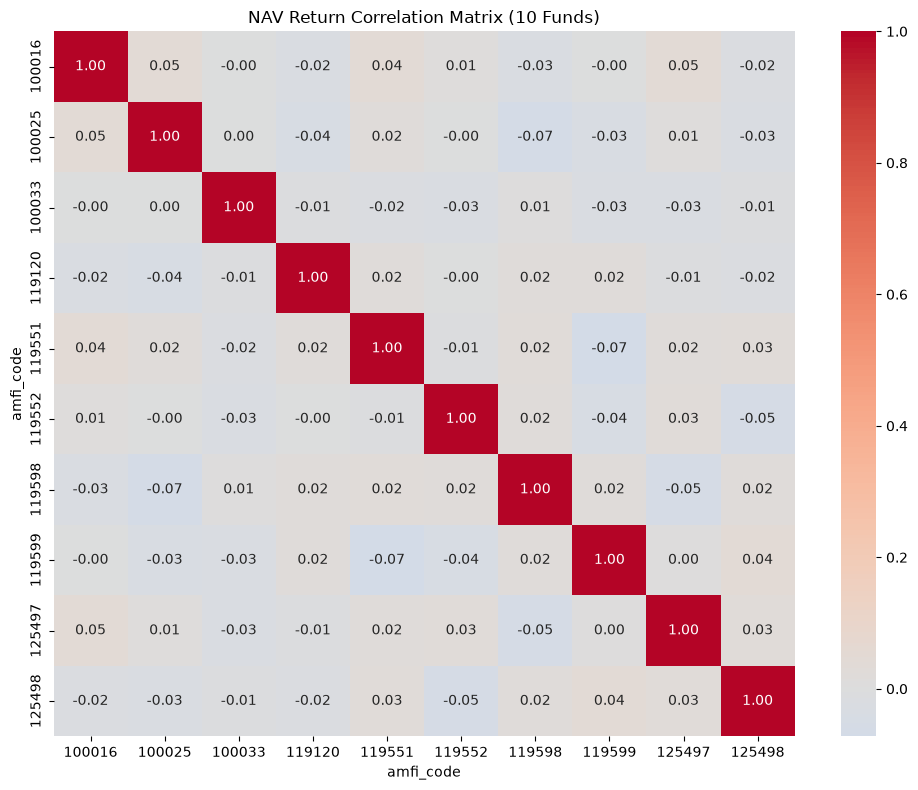

In [11]:
# Pick 10 funds and pivot NAV into wide format, then compute daily returns
top10_codes = fund_master["amfi_code"].head(10).tolist()
nav_subset = nav[nav["amfi_code"].isin(top10_codes)]

nav_wide = nav_subset.pivot(index="nav_date", columns="amfi_code", values="nav")
returns_wide = nav_wide.pct_change().dropna()

corr_matrix = returns_wide.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("NAV Return Correlation Matrix (10 Funds)")
plt.tight_layout()
plt.savefig("../reports/charts/08_correlation_matrix.png", dpi=200)
plt.show()

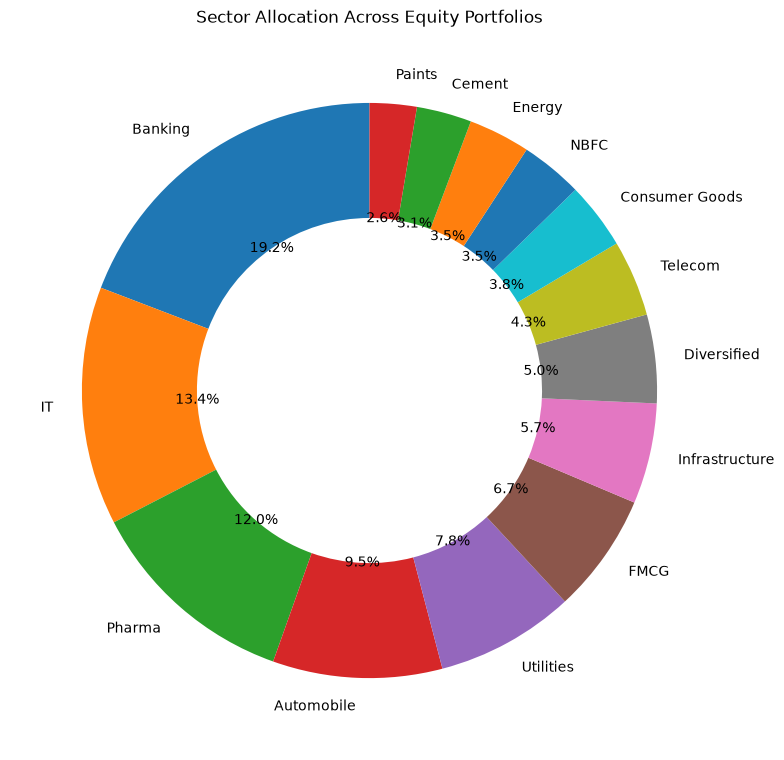

In [12]:
sector_weights = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sector_weights, labels=sector_weights.index, autopct="%1.1f%%", startangle=90,
       wedgeprops=dict(width=0.4))
ax.set_title("Sector Allocation Across Equity Portfolios")
plt.tight_layout()
plt.savefig("../reports/charts/09_sector_allocation.png", dpi=200)
plt.show()

### Chart 7 — Industry folio count growth

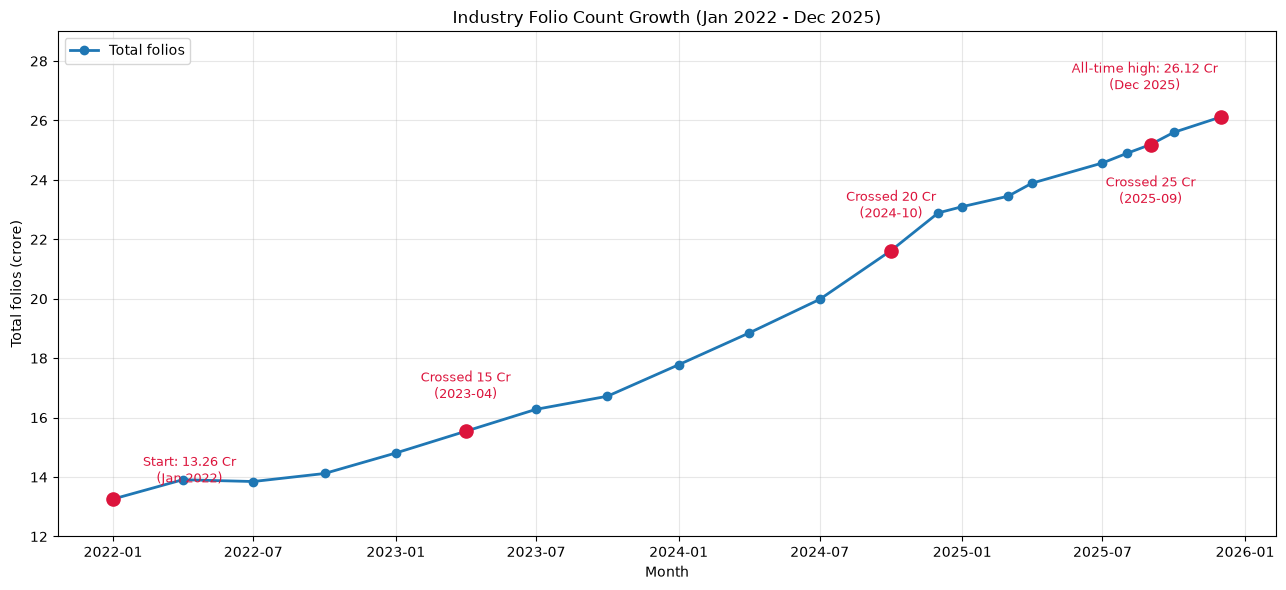

In [13]:
folios["month_dt"] = pd.to_datetime(folios["month"])
folios = folios.sort_values("month_dt").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(folios["month_dt"], folios["total_folios_crore"], marker="o", lw=2,
        color="#1f77b4", label="Total folios")

# milestones: start, end, and the first month each threshold is crossed
start_val = folios["total_folios_crore"].iloc[0]
end_val = folios["total_folios_crore"].iloc[-1]
marks = [(0, "Start: {:.2f} Cr@(Jan 2022)".format(start_val), (55, 12))]
for threshold in [15, 20, 25]:
    crossed = folios.index[folios["total_folios_crore"] >= threshold]
    if len(crossed):
        i = crossed[0]
        marks.append((i, "Crossed {} Cr@({})".format(threshold, folios["month"].iloc[i]), (0, -42) if threshold == 25 else (0, 24)))
marks.append((len(folios) - 1, "All-time high: {:.2f} Cr@(Dec 2025)".format(end_val), (-55, 20)))

for i, label, offset in marks:
    x, y = folios["month_dt"].iloc[i], folios["total_folios_crore"].iloc[i]
    ax.scatter([x], [y], s=90, color="crimson", zorder=5)
    ax.annotate(label.replace("@", "\n"), (x, y), textcoords="offset points",
                xytext=offset, fontsize=9, ha="center", color="crimson")

ax.set_title("Industry Folio Count Growth (Jan 2022 - Dec 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Total folios (crore)")
ax.set_ylim(12, 29)
ax.grid(alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(f"{CHARTS}/07_folio_count_growth.png", dpi=200)
plt.show()


### Chart 11 — Folio mix by asset class

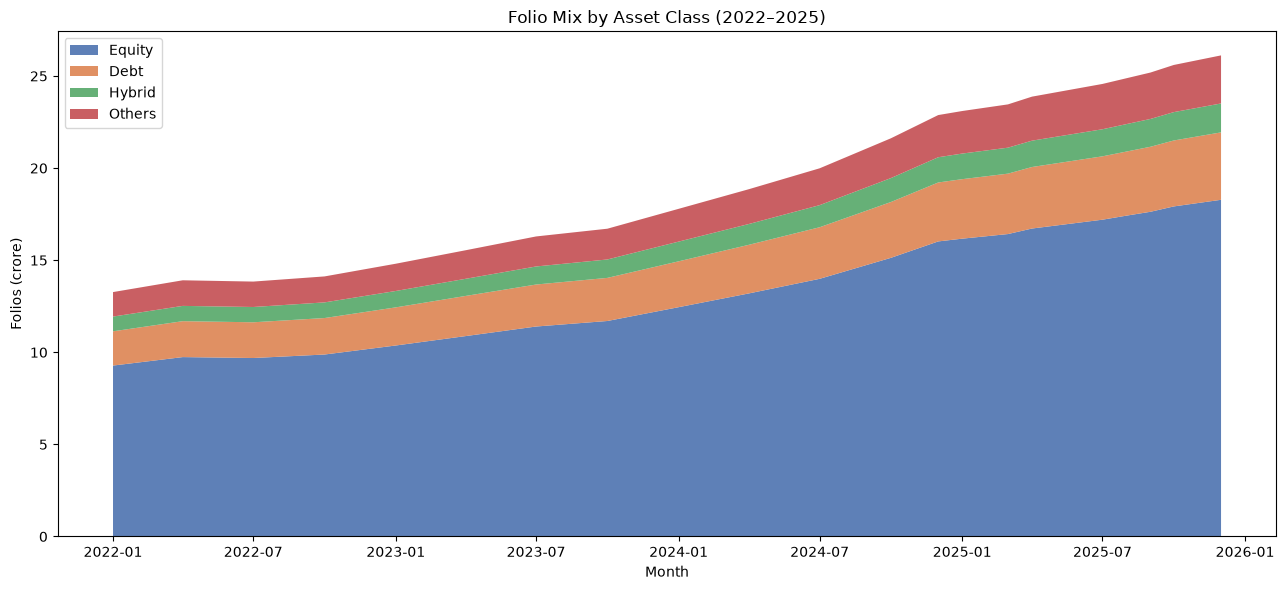

In [14]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.stackplot(folios["month_dt"],
             folios["equity_folios_crore"], folios["debt_folios_crore"],
             folios["hybrid_folios_crore"], folios["others_folios_crore"],
             labels=["Equity", "Debt", "Hybrid", "Others"],
             colors=["#4C72B0", "#DD8452", "#55A868", "#C44E52"], alpha=0.9)
ax.set_title("Folio Mix by Asset Class (2022–2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Folios (crore)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(f"{CHARTS}/11_folio_mix_by_asset_class.png", dpi=200)
plt.show()

### Chart 12 — Normalised NAV growth (base 100) by category

In [15]:
nav_cat = nav.merge(fund_master[["amfi_code", "category"]], on="amfi_code", how="left")
first = nav_cat.sort_values("nav_date").groupby("amfi_code")["nav"].transform("first")
nav_cat["indexed"] = nav_cat["nav"] / first * 100

cat_curve = nav_cat.groupby(["nav_date", "category"])["indexed"].mean().reset_index()

fig = px.line(cat_curve, x="nav_date", y="indexed", color="category",
              title="Normalised NAV Growth by Category (Base 100 = Jan 2022)")
fig.update_layout(height=500, xaxis_title="Date", yaxis_title="Indexed NAV")
fig.show()
fig.write_image(f"{CHARTS}/12_normalised_nav_by_category.png")

### Chart 13 — Expense ratio: Regular vs Direct plans

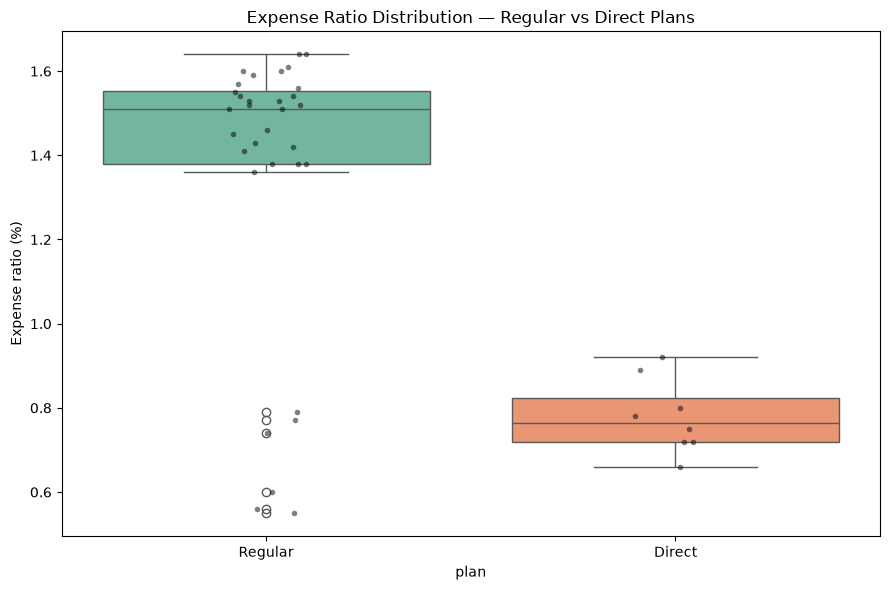

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=fund_master, x="plan", y="expense_ratio_pct", hue="plan",
            palette="Set2", legend=False, ax=ax)
sns.stripplot(data=fund_master, x="plan", y="expense_ratio_pct",
              color="black", alpha=0.5, size=4, ax=ax)
ax.set_title("Expense Ratio Distribution — Regular vs Direct Plans")
ax.set_ylabel("Expense ratio (%)")
plt.tight_layout()
plt.savefig(f"{CHARTS}/13_expense_ratio_by_plan.png", dpi=200)
plt.show()

### Chart 14 — Monthly gross flows by transaction type

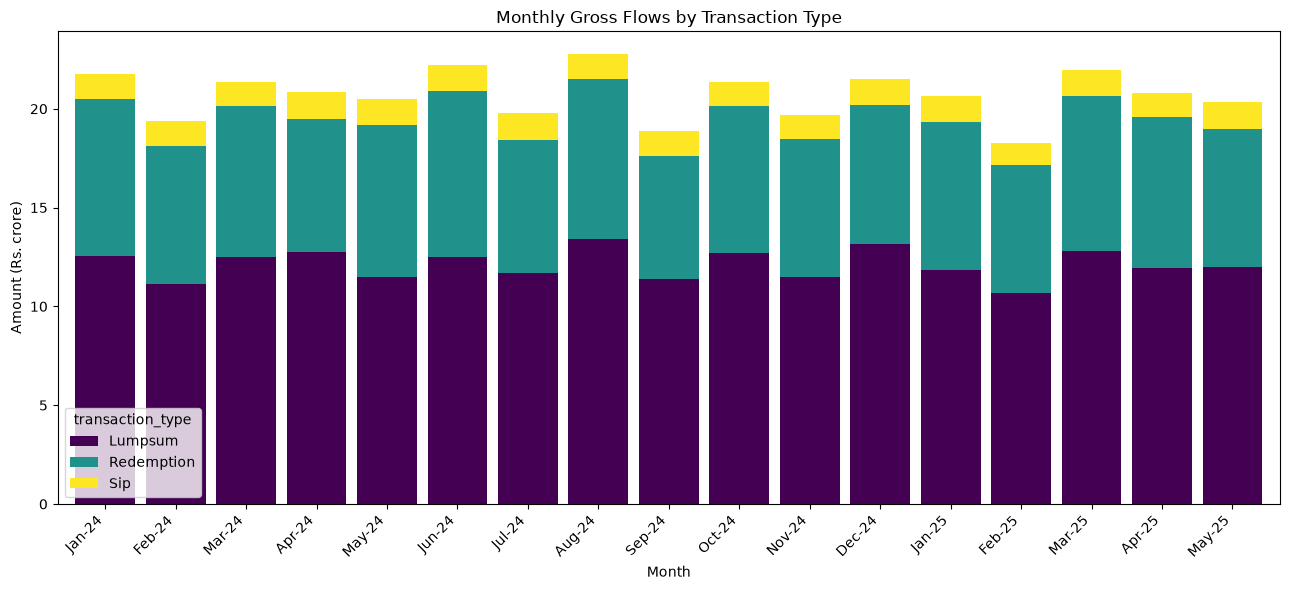

In [17]:
tx = transactions.copy()
tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])
tx["month"] = tx["transaction_date"].dt.strftime("%b-%y")
order = (tx.sort_values("transaction_date")["month"].drop_duplicates().tolist())

flows = (tx.groupby(["month", "transaction_type"])["amount_inr"].sum()
           .unstack(fill_value=0) / 1e7).reindex(order)  # to Rs. crore

fig, ax = plt.subplots(figsize=(13, 6))
flows.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", width=0.85)
ax.set_title("Monthly Gross Flows by Transaction Type")
ax.set_xlabel("Month")
ax.set_ylabel("Amount (Rs. crore)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{CHARTS}/14_monthly_flows_by_type.png", dpi=200)
plt.show()


### Chart 15 — Net category inflow, ranked (Apr 2024 – Mar 2025)

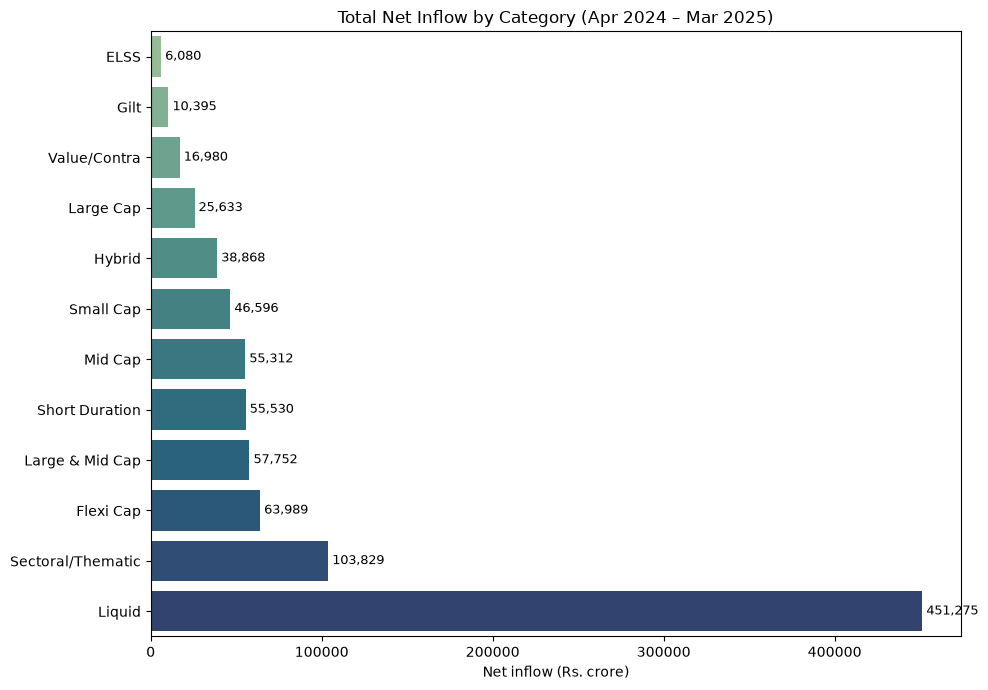

In [18]:
cat_total = (category_inflows.groupby("category")["net_inflow_crore"].sum()
             .sort_values())

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=cat_total.values, y=cat_total.index, hue=cat_total.index,
            palette="crest", legend=False, ax=ax)
for i, v in enumerate(cat_total.values):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=9)
ax.set_title("Total Net Inflow by Category (Apr 2024 – Mar 2025)")
ax.set_xlabel("Net inflow (Rs. crore)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{CHARTS}/15_category_net_inflow_ranked.png", dpi=200)
plt.show()

### Chart 16 — SIP accounts and SIP AUM

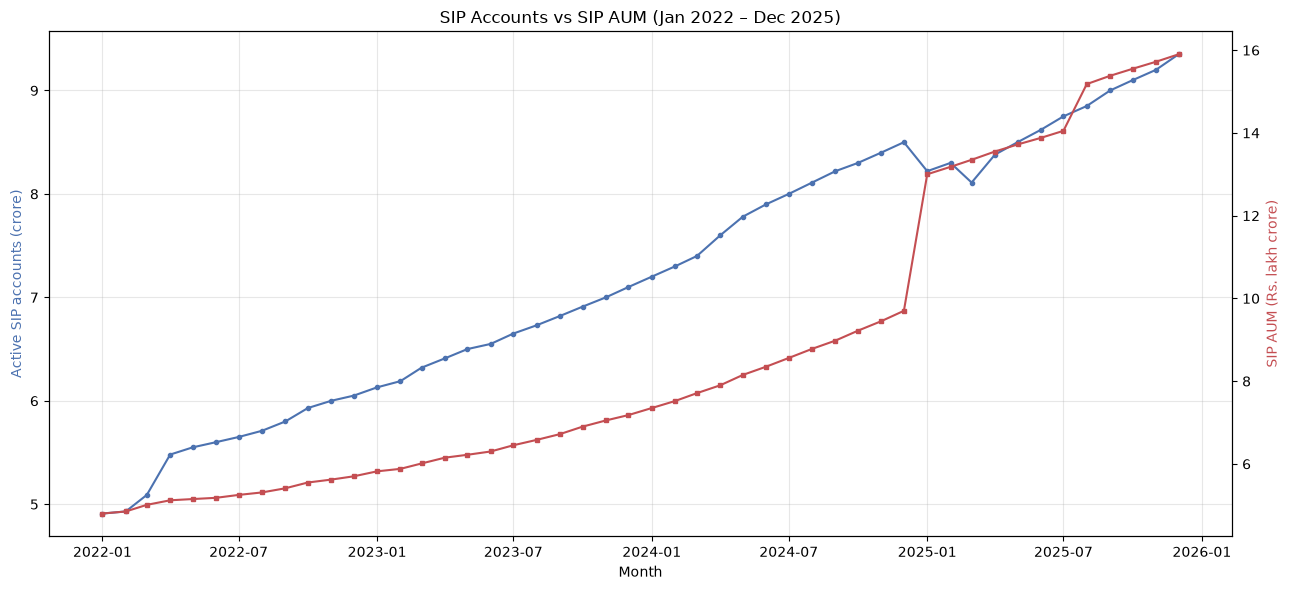

In [19]:
fig, ax1 = plt.subplots(figsize=(13, 6))
ax1.plot(sip["month"], sip["active_sip_accounts_crore"], color="#4C72B0",
         marker="o", ms=3, label="Active SIP accounts (Cr)")
ax1.set_ylabel("Active SIP accounts (crore)", color="#4C72B0")
ax1.set_xlabel("Month")

ax2 = ax1.twinx()
ax2.plot(sip["month"], sip["sip_aum_lakh_crore"], color="#C44E52",
         marker="s", ms=3, label="SIP AUM (Rs. lakh Cr)")
ax2.set_ylabel("SIP AUM (Rs. lakh crore)", color="#C44E52")

ax1.set_title("SIP Accounts vs SIP AUM (Jan 2022 – Dec 2025)")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CHARTS}/16_sip_accounts_vs_aum.png", dpi=200)
plt.show()

### Chart 17 — 30-day rolling volatility of the 10 selected funds

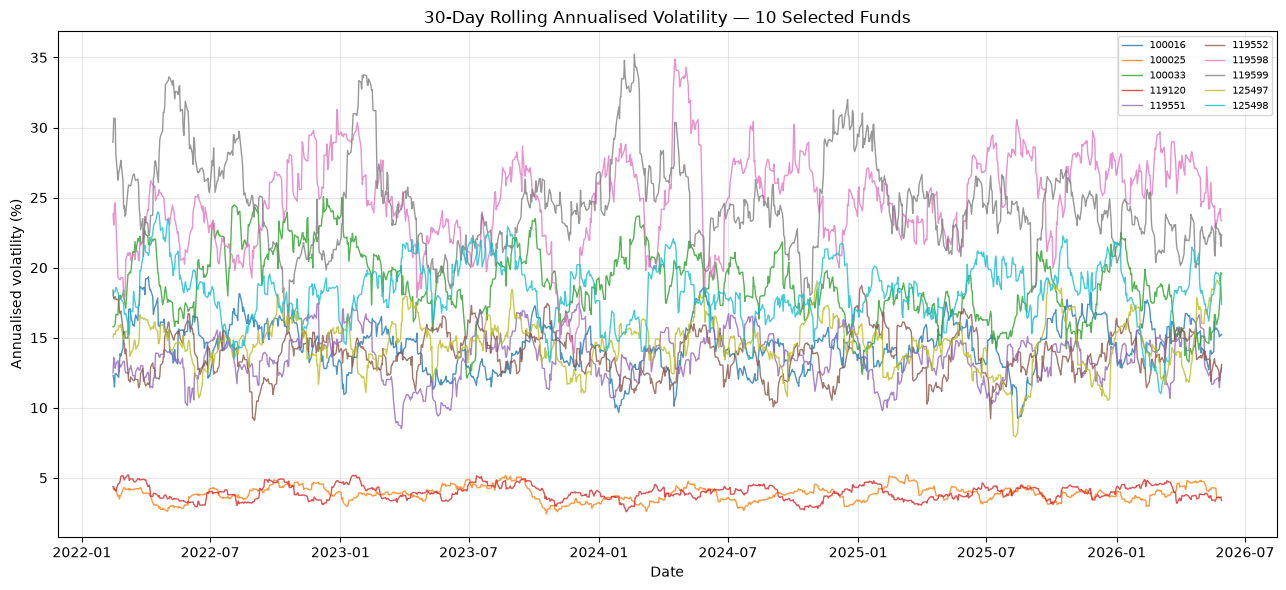

In [20]:
roll_vol = returns_wide.rolling(30).std().dropna() * (252 ** 0.5) * 100

fig, ax = plt.subplots(figsize=(13, 6))
for c in roll_vol.columns:
    ax.plot(roll_vol.index, roll_vol[c], lw=1, alpha=0.8, label=c)
ax.set_title("30-Day Rolling Annualised Volatility — 10 Selected Funds")
ax.set_xlabel("Date")
ax.set_ylabel("Annualised volatility (%)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CHARTS}/17_rolling_volatility.png", dpi=200)
plt.show()

## Key EDA Findings

1. **NAV levels are not comparable across funds** — launch NAVs differ by an order of
   magnitude, so absolute NAV lines say nothing about performance; the category curves must be
   rebased to 100 before they can be read. *(Chart 1, Chart 12)*
2. **SBI Mutual Fund is the clear AUM leader** — it grows from ₹6.05L Cr (Mar 2022) to
   **₹12.5L Cr (Dec 2025)**, roughly 16% ahead of ICICI Prudential (₹10.74L Cr) and 34% ahead of
   HDFC (₹9.30L Cr). *(Chart 2)*
3. **SIP inflows grew almost monotonically for 48 straight months**, from ~₹11.3k Cr in Jan 2022
   to an all-time high of **₹31,002 Cr in Dec 2025** — a ~2.7x rise with no sustained
   drawdown, i.e. SIP money behaved as a shock absorber rather than a pro-cyclical flow.
   *(Chart 3, Chart 16)*
4. **Liquid funds dominate the inflow heatmap and distort it** — ₹4.51L Cr of the FY25 net
   inflow is Liquid (peaking at ₹41,952 Cr in Aug 2024), ~4x the next category
   (Sectoral/Thematic, ₹1.04L Cr). These are treasury flows, not retail conviction, so the
   equity story only becomes visible once Liquid is set aside. *(Chart 4, Chart 15)*
5. **The investor base is young and concentrated** — 26–35 is the largest age group at
   **41.1%** of transactions and 36–45 adds 24.9%, so two thirds of activity comes from
   investors under 46. Median SIP size, though, is nearly flat across ages
   (₹5,020 for 18–25 vs ₹5,420 for 56+) — age drives *how many* SIPs, not how big.
   Gender split is **66.5% male / 33.5% female**. *(Chart 5)*
6. **SIP money is geographically flat, not metro-led** — Madhya Pradesh (₹20.7 Cr),
   Punjab (₹20.1 Cr) and Telangana (₹18.6 Cr) top the state table, and the top state leads
   the fifth by only ~13%. City tier is **66.3% T30 / 33.7% B30**, so B30 already supplies a
   third of transactions. *(Chart 6)*
7. **Folio count nearly doubled**, from **13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025)** — ~97%
   growth in four years. Equity folios drove it (9.28 Cr → 18.28 Cr) and their share of the
   total held steady at ~70%, so account growth was broad-based rather than a rotation into
   equity. *(Chart 7, Chart 11)*
8. **The daily-return correlation matrix is effectively empty** — pairwise correlations
   sit between –0.07 and +0.05 with a mean of –0.003. Real large-cap equity funds move
   together at 0.85–0.95, so this matrix cannot be used for diversification decisions
   as-is. *(Chart 8 — see finding 10)*
9. **Equity portfolios are financials-and-tech heavy** — Banking (19.2%), IT (13.4%) and
   Pharma (12.0%) account for **44.6%** of aggregate holding weight across all equity funds;
   the top six sectors reach 68.6%. Concentration this high means the "diversified equity"
   label understates single-sector exposure. *(Chart 9)*
10. **Anomaly — the NAV series is synthetic.** Regular and Direct plans of the *same*
    scheme (e.g. HDFC Top 100 Regular vs Direct) correlate at only **0.047** on daily returns;
    they hold an identical portfolio and should correlate at ~0.999, differing only by the
    expense-ratio drag (Direct averages 0.78% vs Regular 1.35%, Chart 13). Day-to-day NAV moves
    were therefore generated independently per scheme. Annual medians still look plausible
    (2022 +14.4%, 2023 +14.5%, 2024 +7.1%, 2025 +15.8%), so **level/trend analysis is usable but
    any daily-return statistic — correlation, beta, volatility — is not.**
    *(Charts 8, 13, 17)*